# libraries


In [8]:
import pandas as pd
import numpy as np
import math
import scipy
import matplotlib.pyplot as plt
import sklearn 
import xarray as xr
from sklearn.tree import DecisionTreeRegressor
import os
import matplotlib.patches as mpl_patches
os.chdir('C:/Users/leoge/OneDrive/Documents/Centrale Nantes/ei4/R&D')

# SETUP

## setup definition

In [9]:
size_test=0.25

# time span
time_range_min=-12000 #a cal. years BP
time_range_max=0   #in cal. years BP 0 = 1950 AD (Anno Domini: "après JC")
# spatial span ; span used in the paper
lat_min,lat_max=45,55 # degree north
lon_min,lon_max=90,100 # degree east

# measurments lakes
lakes=['M14','M15','O6','O14','O15','O16']
lat=[50.0755555556,49.7858333333,49.8213888889,50.0283333333,50.0080555556,50.0186111111]
lon=[-95.4022222222,-95.1902777778,-94.7836111111,-94.8244444444,-94.9825,-94.8508333333]
altitude=[330,337,361,332,339,337]
measurments=pd.DataFrame({'Lake':lakes,'lat':lat,'lon':lon,'altitude':altitude})

lat_meas=measurments.describe().loc['mean'].lat
lon_meas=measurments.describe().loc['mean'].lon
lat_meas,lon_meas #degree north, degree east

time_resolution= 50 #in a cal. years BP
time_array=np.arange(time_range_min,time_range_max+time_resolution,time_resolution ) #in cal. years BP



## Load PRECT and TS data

In [10]:
#Precipitation rate #decadal mean annual # averages 22ka-2000AD 
#PRECT = Total precipitation rate: PRECC+PRECL #PRECC = Convective precipitation rate #PRECL = Large-scale (stable) precipitation rate

PRECT = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.PRECT.nc')
PRECT = PRECT.sel(lat=lat_meas,lon=360+lon_meas,method='nearest')
PRECT=PRECT.rename({'time':'Age'})
PRECC = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECC':PRECT.PRECC.values})
PRECL = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECL':PRECT.PRECL.values})
PRECT = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECT':PRECT.PRECT.values})

#Temperature Surface
TS = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.TS.nc')
TS = TS.sel(lat=lat_meas,lon=360+lon_meas,method='nearest')
TS=TS.rename({'time':'Age'})
TS = pd.DataFrame({'Age':TS.Age.values*1000,'TS':TS.TS.values})

AnnTemp = pd.read_csv('./25155593/AnnTemp.csv')
AnnTemp=AnnTemp[['Age','AnnTemp']].dropna()
AnnTemp = AnnTemp.reindex(index=AnnTemp.index[::-1]).reset_index(drop=True)
AnnTemp.Age=AnnTemp.Age*(-1)
Human = pd.read_csv('./25155593/Human.csv')
Human = Human.reindex(index = Human.index[::-1]).reset_index(drop=True)
Human.Age = Human.Age /(-1) #conversion to 12000 to 0 

## Load fire data

In [11]:
# Fire frequency
FF = pd.read_csv('./25155593/FFBootCISap.csv')
FF= FF.reindex(index=FF.index[::-1]).reset_index(drop=True)
FF.Age = FF.Age /(-1)
# burning biomass
BB = pd.read_csv('./25155593/BBBootCISap.csv')
BB = BB.reindex(index=BB.index[::-1]).reset_index(drop=True)
BB.Age = BB.Age/(-1)
#FS = FF/BB
FS = pd.read_csv('./25155593/FSBootCISap.csv')
FS = FS.reindex(index=FS.index[::-1]).reset_index(drop=True)
FS.Age = FS.Age/(-1)

FF=FF.rename(columns={'Mean':'FF_Mean'})
FS=FS.rename(columns={'Mean':'FS_Mean'})
BB=BB.rename(columns={'Mean':'BB_Mean'})

In [12]:
list_vars=['TS','PRECT','human'] # ,'PRECC','PRECL'
list_df=[TS,PRECT,Human] # ,PRECC,PRECL

dict={'Age':time_array}
for i in range (len(list_vars)):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_vars[i]].values)
    mean_3_to_5_ka= list_df[i].loc[(list_df[i].Age < -3000) & (list_df[i].Age > -5000)][list_vars[i]].mean()
    f_interp = f_interp - mean_3_to_5_ka
    dict.update({list_vars[i]:f_interp})

list_df=[BB,FF,FS]
list_var= ['BB_Mean','FF_Mean','FS_Mean']
dict2={'Age':time_array}
n=len(list_df)
for i in range (0,n):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_var[i]].values)
    dict2.update({list_var[i]:f_interp})

dict.update(dict2)

df_annual = pd.DataFrame(dict)
df_annual.Age = time_array # convert -12 ka to 12000 cal. years BP

# Age from 12000 to 0 cal. years BP with a 50 years time_step
# all data compared to the mean from 5000 to 3000 cal. yers BP (publication)
# TS in K
# PRECT, PRECC and PRECL in m/d (hence the 10E-9)

## Load pollen data

In [13]:
Pollen50Reg = pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg
cols_pollen=Pollen50Reg.columns

Pollen50Reg.Age = Pollen50Reg.Age # turn age into -12 to 0 ka cal. years BP (same as environmental data)
Pollen50Reg = Pollen50Reg.iloc[::-1].reset_index(drop=True)

time_pollen= time_array #np.arange(0,np.max(Pollen50Reg.Age.values),50)
df=Pollen50Reg
df.Age=df.Age*(-1)
cols=df.columns
dict = {'Age':time_pollen}
for x in cols:
    fp=df[x].values
    f_interp=np.interp(x=time_pollen,xp=df.Age,fp=fp)
    dict.update({x:f_interp})

Pollen50Reg=pd.DataFrame(dict)
Pollen50Reg.Age=Pollen50Reg.Age


# type of plants by family
conifers = Pollen50Reg.columns[1:6]
deciduous = Pollen50Reg.columns[6:12]
herbaceous = Pollen50Reg.columns[12:-1]
aquatics =Pollen50Reg.columns[-1:]


# CORRELATION

Text(0.5, 1.0, 'Spearman correlation with environmental')

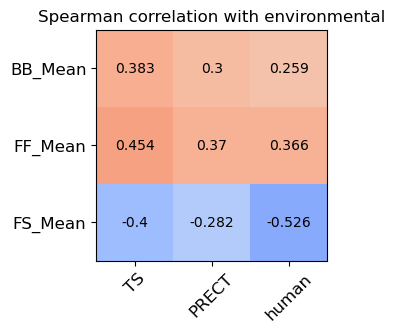

In [14]:
mat_spearman=df_annual.corr(method='spearman').iloc[-3:,1:-3]
mat_spearman
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(mat_spearman,cmap='coolwarm',vmin=-1,vmax=1,origin='upper')
nrow,ncol=mat_spearman.shape

for i in range(nrow):
    for j in range(ncol):
        c=mat_spearman.iloc[i,j]
        ax.text(j,i,round(c,3),va='center',ha='center',color='k',size=10)

ax.set_xticks(np.arange(0,len(list_vars),1),labels=list_vars,size=12,rotation=45)       
ax.tick_params(axis="x", bottom=True,top=False, labelbottom=True,labeltop=False)
ax.set_yticks(np.arange(0,len(list_var),1),labels=list_var,size=12)  
ax.set_title('Spearman correlation with environmental')  

Text(0.5, 1.0, 'Pearson correlation with environmental')

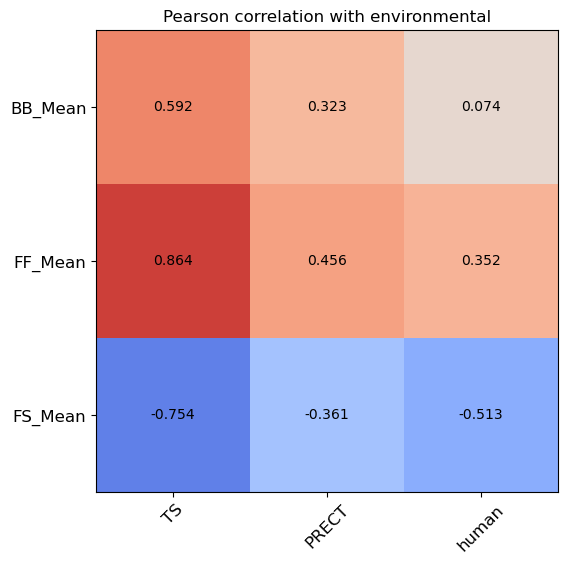

In [15]:
mat_pearson=df_annual.corr(method='pearson').iloc[-3:,1:-3]
mat_pearson
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(mat_pearson,cmap='coolwarm',vmin=-1,vmax=1,origin='upper')
nrow,ncol=mat_pearson.shape

for i in range(nrow):
    for j in range(ncol):
        c=mat_pearson.iloc[i,j]
        ax.text(j,i,round(c,3),va='center',ha='center',color='k',size=10)

ax.set_xticks(np.arange(0,len(list_vars),1),labels=list_vars,size=12,rotation=45)       
ax.tick_params(axis="x", bottom=True,top=False, labelbottom=True,labeltop=False)
ax.set_yticks(np.arange(0,len(list_var),1),labels=list_var,size=12)  
ax.set_title('Pearson correlation with environmental')  

Text(0.5, 1.0, 'TS vs FF_Mean\nSpearman coefficient = 0.4539582\nPearson = 0.86416983')

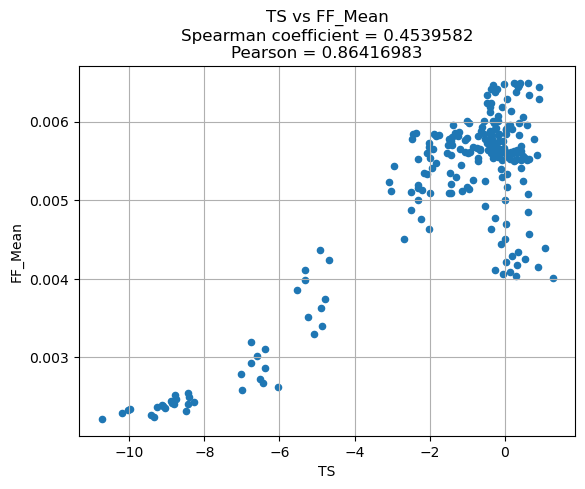

In [16]:
x_data='TS'
y_data='FF_Mean'
correl_method='Spearman'
cc_spearman=mat_spearman[x_data].loc[y_data]
cc_pearson=mat_pearson[x_data].loc[y_data]

#plot
df_annual.plot.scatter(x=x_data,y=y_data)
plt.grid()
plt.title(x_data+' vs '+y_data +'\n'+ correl_method+' coefficient = '+np.array2string(cc_spearman) + '\n' + 'Pearson = '+np.array2string(cc_pearson) )

Text(0.5, 1.0, 'PRECT vs FF_Mean\nSpearman0.37014677\nPearson = 0.45627395')

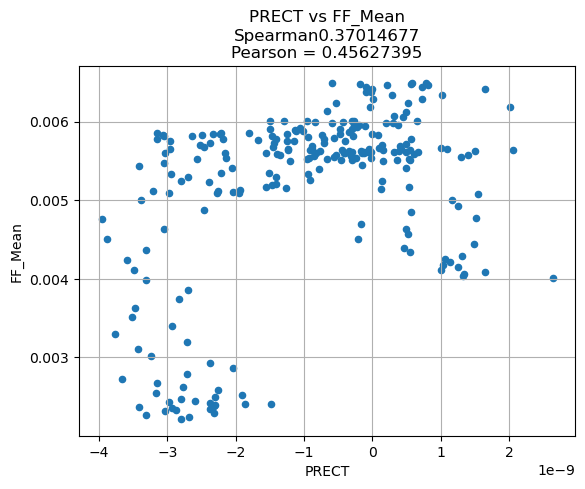

In [17]:
x_data='PRECT'
y_data='FF_Mean'
correl_method='Spearman'
cc_spearman=mat_spearman[x_data].loc[y_data]
cc_pearson=mat_pearson[x_data].loc[y_data]

#plot
df_annual.plot.scatter(x=x_data,y=y_data)
plt.grid()
plt.title(x_data+' vs '+y_data +'\n'+ correl_method + np.array2string(cc_spearman) + '\n'+ 'Pearson = '+np.array2string(cc_pearson))

# MODELS

In [18]:
def cross_score(model, X, y ):
        """ Arguments 
        - model
        - X features
        - y target
        Returns
        cross val score for R-squared (r2), 
        mean absolute value (mae),
        mean square error (mse),
        root mean squared error (rmse)
        """
        from sklearn.model_selection import LeaveOneOut, cross_val_score
        cv=LeaveOneOut()
        r2=cross_val_score(model,X,y, scoring='r2',cv=cv,n_jobs=-1)

        mae=cross_val_score(model,X,y,
                            scoring='neg_mean_absolute_error',
                            cv=cv, 
                            n_jobs=-1) 
        mse=cross_val_score(model,X,y,
                                scoring='neg_mean_squared_error',
                                cv=cv,
                                n_jobs=-1)
        rmse=cross_val_score(model,X,y,
                                scoring='neg_root_mean_squared_error',
                                cv=cv,
                                n_jobs=-1)

        df=pd.DataFrame(data={'r2':r2,'mae':mae,'mse':mse,'rmse':rmse})
        return df

## TS, PRECT linear regression

R-squared: 0.7664
Mean squared error: 0.0000
Root mean squared error: 0.0006
Intercept: 0.005697723742810491

Feature Coefficients:
   Feature    Coefficient
0      TS       0.000483
1   PRECT -287492.028643


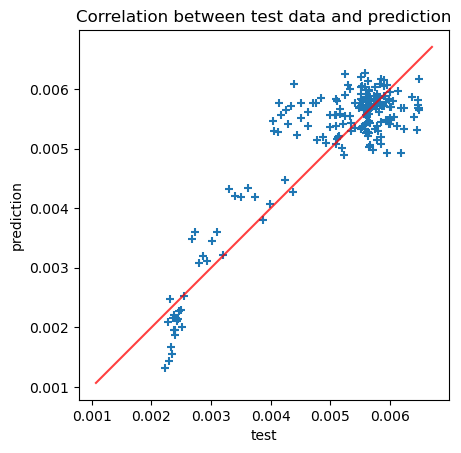

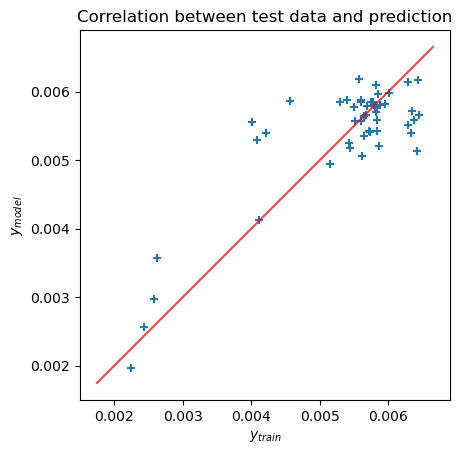

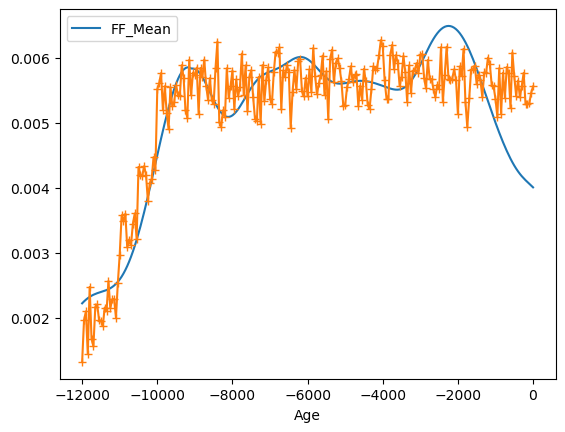

In [19]:
# Import train_test_split.
from sklearn.model_selection import train_test_split

# Create features X and target y.
X = df_annual[['TS','PRECT']]
y = df_annual.FF_Mean  

# Split the dataset into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler.
scaler = StandardScaler()
#utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.

# Fit and transform training data.
X_train_scaled = X_train # scaler.fit_transform(X_train)   # X_train

# Also transform test data.
X_test_scaled = X_test #scaler.transform(X_test)    # X_test 

# Import LinearRegression.
from sklearn.linear_model import LinearRegression

# Instantiate linear regression model.
model = LinearRegression()
# Fit the model to the training data.
model.fit(X_train_scaled, y_train)

# Make predictions on the testing data.
y_pred = model.predict(X_test_scaled)

############ performance of model #################""
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score

# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")
# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")


########### linear regression coefficient ##########""
b=model.intercept_
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nFeature Coefficients:\n", coeff_df)

fig, ax = plt.subplots()

ax.scatter(x=y_test,y=y_pred,marker='+')
ax.set_xlabel('test')
ax.set_ylabel('prediction')
ax.set_title('Correlation between test data and prediction')
ax.set_aspect('equal',adjustable='box')
ax=plt.gca()
# plt.axis('square')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)

df_model_train=X_train

# multiply all columns with their respective coefficient
for i in range(len(coeff_df.Coefficient)):
    df_model_train.iloc[:,i] = X_train.iloc[:,i]*coeff_df.Coefficient.values[i]

# add all columns 
df_model_train = df_model_train.sum(axis=1)

fig, ax = plt.subplots()

ax.scatter(x=y_train,y=b+df_model_train,marker='+')
ax.set_xlabel(r'$y_{train}$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Correlation between test data and prediction')
ax.set_aspect('equal',adjustable='box')
ax=plt.gca()
# plt.axis('square')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)

#### dataframe of obtained model
df_model=X

# multiply all columns with their respective coefficient
for i in range(len(coeff_df.Coefficient)):
    df_model.iloc[:,i] = X.iloc[:,i]*coeff_df.Coefficient.values[i]

# add all columns 
df_model = df_model.sum(axis=1)

# figure
fig, ax = plt.subplots()
df_annual.plot(x='Age',y='FF_Mean',ax=ax)
ax.plot(df_annual['Age'],b+df_model,label='model',marker='+',linestyle='-')


## TS et PRECT

R-squared: 0.8164485936221052
Mean squared error: 2.7485770527401484e-07
Root mean squared error: 0.0005242687338321969
Intercept: 0.005145654944444444

Feature Coefficients:
   Feature  Coefficient
0      TS     0.001134
1   PRECT    -0.000266
R-squared: 0.7597009537743045
Mean squared error: 3.014470768082953e-07


C:\Users\leoge\AppData\Local\Temp\ipykernel_12336\3772129406.py:172: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


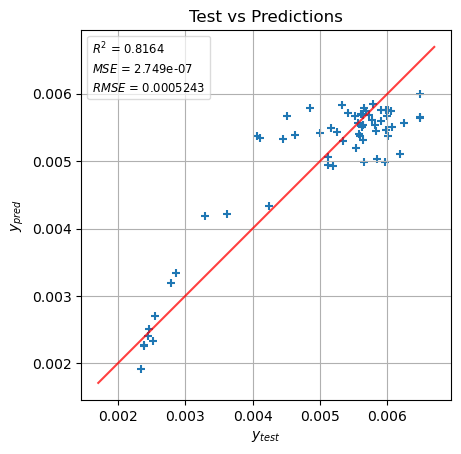

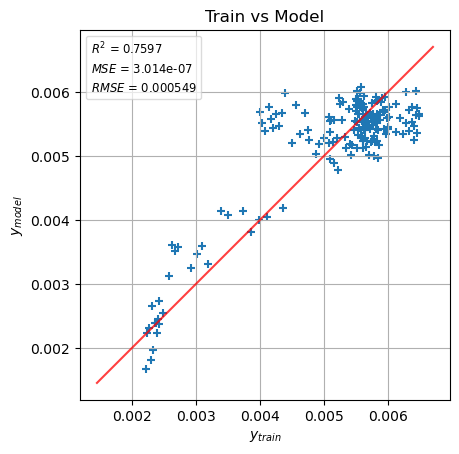

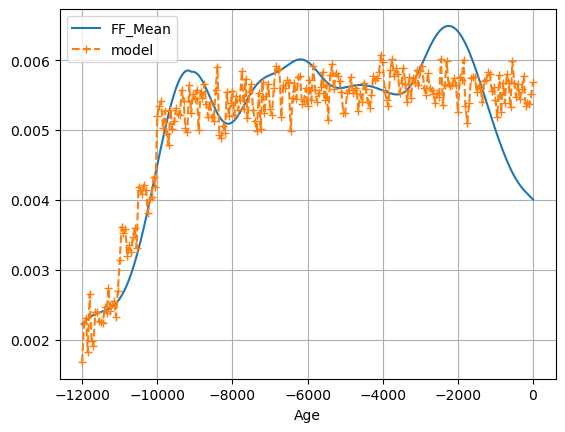

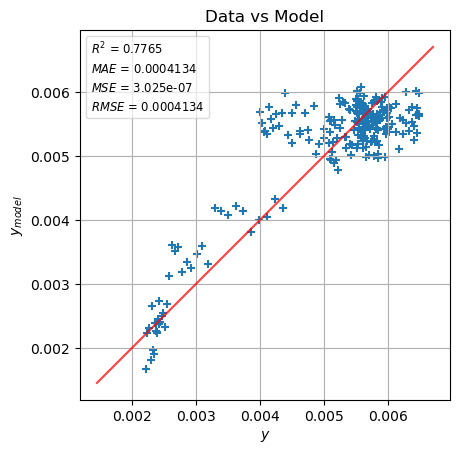

In [20]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score


# Create features X and target y.
X = df_annual[['TS','PRECT']]
y = df_annual.FF_Mean  

# Split the dataset into training (usually 75%) and testing (25%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(X_train)   # X_train
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
# Also transform test data.
X_test_scaled = scaler.transform(X_test)    # X_test 
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)


# Instantiate linear regression model.
model = LinearRegression()
# Fit the model to the training data.
model.fit(X_train_scaled, y_train)

# Make predictions on the testing data.
y_pred = model.predict(X_test_scaled)

############ performance of model #################""
# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")
# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse}")
# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse}")
# accuracy = accuracy_score(y_test,y_pred)
# print(f"Accuracy score: {accuracy:.4f}")

########### linear regression coefficient ##########""
b=model.intercept_
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nFeature Coefficients:\n", coeff_df)

############# plot correlation plots #######################
fig, ax = plt.subplots()

ax.scatter(x=y_test,y=y_pred,marker='+')
ax.set_xlabel(r'$y_{test}$')
ax.set_ylabel(r'$y_{pred}$')
ax.set_title('Test vs Predictions')
# squared plot
ax.set_aspect('equal',adjustable='box')
ax=plt.gca()
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# create a list with two empty handles (or more if needed)
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 3

# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)

############ plot for train data #################
# model for X_train
df_model_train=X_train_scaled
# multiply all columns with their respective coefficient
for i in range(len(coeff_df.Coefficient)):
    df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
# add all columns 
df_model_train = df_model_train.sum(axis=1)

fig, ax = plt.subplots()

ax.scatter(x=y_train,y=b+df_model_train,marker='+')
ax.set_xlabel(r'$y_{train}$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Train vs Model')
ax.set_aspect('equal',adjustable='box')
ax=plt.gca()
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()

r2 = r2_score(y_train, b+df_model_train)
print(f"R-squared: {r2}")
# Calculate and print MSE.
mse = mean_squared_error(y_train, b+df_model_train)
print(f"Mean squared error: {mse}")
# Calculate and print RMSE.
rmse = mse ** 0.5
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 3

# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)

#### dataframe of obtained model
df_model=X
X_scaled=scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

# multiply all columns with their respective coefficient
for i in range(len(coeff_df.Coefficient)):
    df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

# add all columns 
df_model = df_model.sum(axis=1)

# figure
fig, ax = plt.subplots()
df_annual.plot(x='Age',y='FF_Mean',ax=ax)
ax.plot(df_annual['Age'],b+df_model,label='model',marker='+',linestyle='--')
ax.legend()
ax.grid()

fig, ax = plt.subplots()
ax.scatter(x=y,y=b+df_model,marker='+')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
r2 = r2_score(y, b+df_model)
mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 4

# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)


R-squared: 0.4241532670728265
Mean squared error: 0.0006425204908495329
Root mean squared error: 0.025347987905345325
Intercept: 0.06345836918435882

Feature Coefficients:
   Feature  Coefficient
0      TS     0.021939
1   PRECT    -0.003911
R-squared: 0.3359310446712692
Mean squared error: 0.0007548647479101022


C:\Users\leoge\AppData\Local\Temp\ipykernel_12336\2917319110.py:172: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


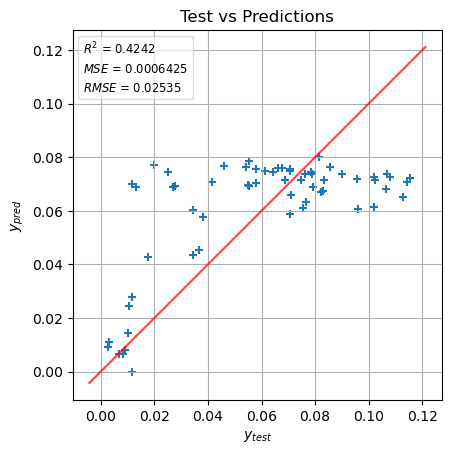

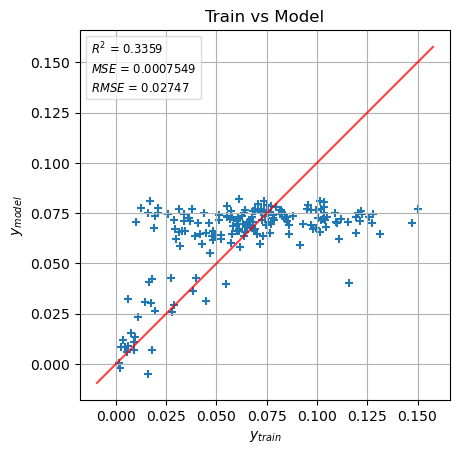

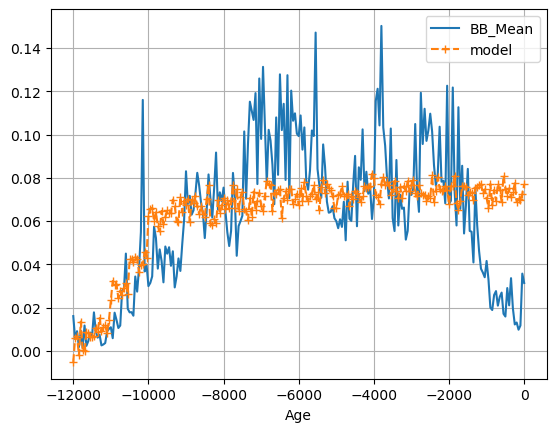

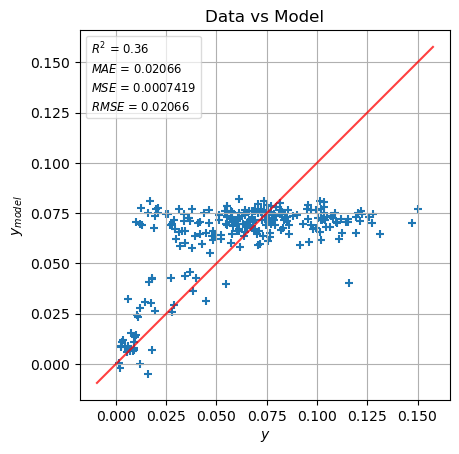

In [21]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score


# Create features X and target y.
X = df_annual[['TS','PRECT']]
y = df_annual.BB_Mean  

# Split the dataset into training (usually 75%) and testing (25%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(X_train)   # X_train
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
# Also transform test data.
X_test_scaled = scaler.transform(X_test)    # X_test 
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)


# Instantiate linear regression model.
model = LinearRegression()
# Fit the model to the training data.
model.fit(X_train_scaled, y_train)

# Make predictions on the testing data.
y_pred = model.predict(X_test_scaled)

############ performance of model #################""
# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")
# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse}")
# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse}")
# accuracy = accuracy_score(y_test,y_pred)
# print(f"Accuracy score: {accuracy:.4f}")

########### linear regression coefficient ##########""
b=model.intercept_
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nFeature Coefficients:\n", coeff_df)

############# plot correlation plots #######################
fig, ax = plt.subplots()

ax.scatter(x=y_test,y=y_pred,marker='+')
ax.set_xlabel(r'$y_{test}$')
ax.set_ylabel(r'$y_{pred}$')
ax.set_title('Test vs Predictions')
# squared plot
ax.set_aspect('equal',adjustable='box')
ax=plt.gca()
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# create a list with two empty handles (or more if needed)
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 3

# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)

############ plot for train data #################
# model for X_train
df_model_train=X_train_scaled
# multiply all columns with their respective coefficient
for i in range(len(coeff_df.Coefficient)):
    df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
# add all columns 
df_model_train = df_model_train.sum(axis=1)

fig, ax = plt.subplots()

ax.scatter(x=y_train,y=b+df_model_train,marker='+')
ax.set_xlabel(r'$y_{train}$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Train vs Model')
ax.set_aspect('equal',adjustable='box')
ax=plt.gca()
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()

r2 = r2_score(y_train, b+df_model_train)
print(f"R-squared: {r2}")
# Calculate and print MSE.
mse = mean_squared_error(y_train, b+df_model_train)
print(f"Mean squared error: {mse}")
# Calculate and print RMSE.
rmse = mse ** 0.5
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 3

# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)

#### dataframe of obtained model
df_model=X
X_scaled=scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

# multiply all columns with their respective coefficient
for i in range(len(coeff_df.Coefficient)):
    df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

# add all columns 
df_model = df_model.sum(axis=1)

# figure
fig, ax = plt.subplots()
df_annual.plot(x='Age',y='BB_Mean',ax=ax)
ax.plot(df_annual['Age'],b+df_model,label='model',marker='+',linestyle='--')
ax.legend()
ax.grid()

fig, ax = plt.subplots()
ax.scatter(x=y,y=b+df_model,marker='+')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
r2 = r2_score(y, b+df_model)
mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 4

# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)


## Pollen linear regression


### set to same time array

In [22]:
df_data = pd.merge(Pollen50Reg, df_annual, how='inner', on=['Age', 'Age'])

Text(0.5, 1.0, 'Pearson correlation with environmental')

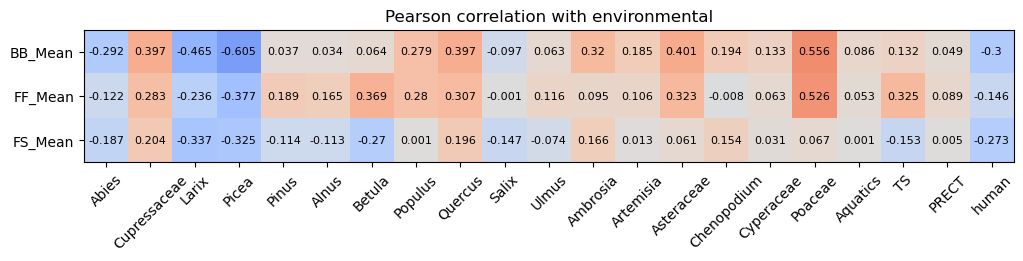

In [25]:
mat_pearson=df_data.corr(method='pearson').iloc[-3:,1:-3]
mat_pearson
fig, ax = plt.subplots(figsize=(12,6))
ax.imshow(mat_pearson,cmap='coolwarm',vmin=-1,vmax=1,origin='upper')
nrow,ncol=mat_pearson.shape
list_vars=df_data.columns[1:-3]

for i in range(nrow):
    for j in range(ncol):
        c=mat_pearson.iloc[i,j]
        ax.text(j,i,round(c,3),va='center',ha='center',color='k',size=8)

ax.set_xticks(np.arange(0,len(list_vars),1),labels=list_vars,size=10,rotation=45)       
ax.tick_params(axis="x", bottom=True,top=False, labelbottom=True,labeltop=False)
ax.set_yticks(np.arange(0,len(list_var),1),labels=list_var,size=10)  
ax.set_title('Pearson correlation with environmental')  

## Pollen & TS linear

### train_test_split

R-squared: 0.18609795135088392
Mean squared error: 0.000817961794938778
Root mean squared error: 0.02860003138003135
Intercept: 0.6435217495032257

Feature Coefficients:
          Feature  Coefficient
0          Abies    -0.003553
1   Cupressaceae     0.007569
2          Larix    -0.025674
3          Picea     0.000416
4          Pinus     0.000716
5          Alnus    -0.000801
6         Betula    -0.010688
7        Populus    -0.003652
8        Quercus    -0.014944
9          Salix    -0.014377
10         Ulmus     0.000932
11      Ambrosia    -0.002414
12     Artemisia    -0.004705
13    Asteraceae    -0.006918
14   Chenopodium     0.002338
15    Cyperaceae     0.002233
16       Poaceae    -0.006371
17      Aquatics     0.013319
18            TS    -0.000187
19         PRECT     0.009730
20         human    -0.008083
R-squared: 0.49290506153005076
Mean squared error: 0.0005219477774491106


C:\Users\leoge\AppData\Local\Temp\ipykernel_7104\939663893.py:179: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


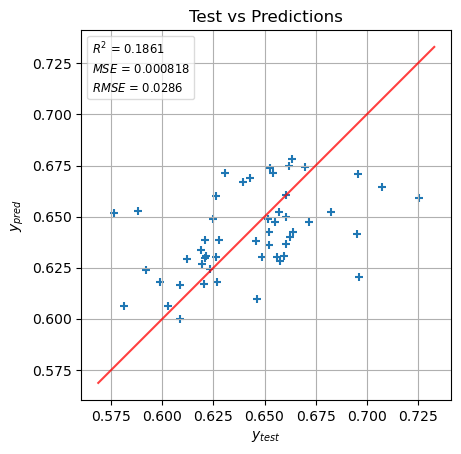

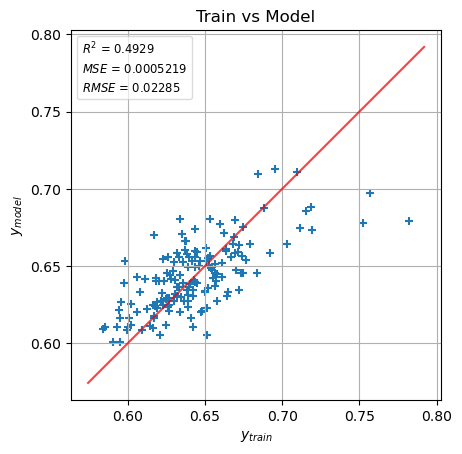

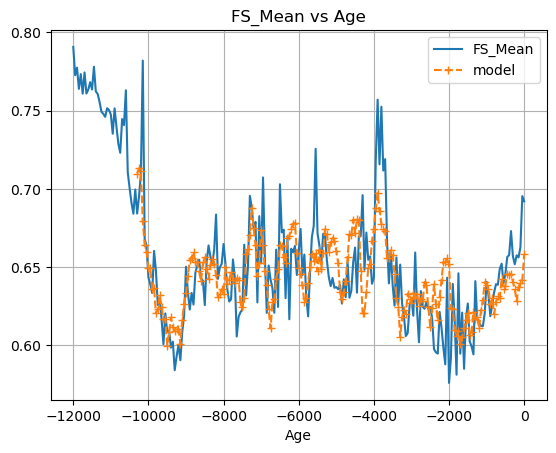

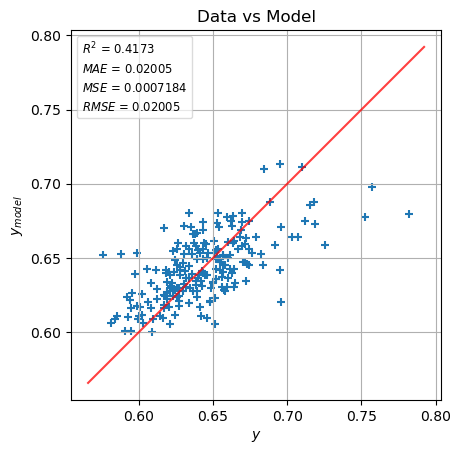

In [41]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
features = df_data.columns.values[1:-3]
y_target=['FS_Mean']#,'FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]
    # Create features X and target y.


    # Split the dataset into training (usually 75%) and testing (25%) sets.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    # tt=100
    # X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    print(f"Root mean squared error: {rmse}")
    # accuracy = accuracy_score(y_test,y_pred)
    # print(f"Accuracy score: {accuracy:.4f}")

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############# plot correlation plots #######################
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel(r'$y_{test}$')
    ax.set_ylabel(r'$y_{pred}$')
    ax.set_title('Test vs Predictions')
    # squared plot
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # create a list with two empty handles (or more if needed)
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)

    fig, ax = plt.subplots()

    ax.scatter(x=y_train,y=b+df_model_train,marker='+')
    ax.set_xlabel(r'$y_{train}$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Train vs Model')
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()

    r2 = r2_score(y_train, b+df_model_train)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_train, b+df_model_train)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure
    fig, ax = plt.subplots()
    df_annual.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.grid()

    fig, ax = plt.subplots()
    ax.scatter(x=y,y=b+df_model,marker='+')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 4

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


In [42]:
coeff_df.Coefficient.values

array([-0.0035528 ,  0.00756938, -0.02567408,  0.00041581,  0.00071621,
       -0.00080135, -0.01068787, -0.00365177, -0.01494428, -0.01437672,
        0.00093189, -0.0024144 , -0.00470529, -0.0069179 ,  0.00233813,
        0.00223273, -0.00637114,  0.01331868, -0.00018705,  0.00973044,
       -0.00808267])

### select features > 0.0001

R-squared: -1.0372919054938095
Mean squared error: 8.95728049877281e-07
Root mean squared error: 0.0009464291045172274
Intercept: 0.005500321570000001

Feature Coefficients:
          Feature  Coefficient
0          Abies     0.000075
1   Cupressaceae    -0.000181
2          Larix     0.000123
3          Picea    -0.000064
4          Pinus     0.000224
5          Alnus     0.000074
6         Betula     0.000103
7     Asteraceae     0.000189
8    Chenopodium    -0.000030
9     Cyperaceae    -0.000167
10       Poaceae     0.000345
11         PRECT     0.000066
R-squared: 0.8219791074510268
Mean squared error: 4.369167521630057e-08


C:\Users\leoge\AppData\Local\Temp\ipykernel_18988\3790751536.py:183: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


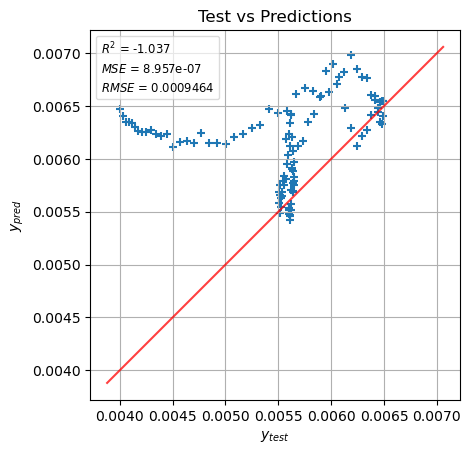

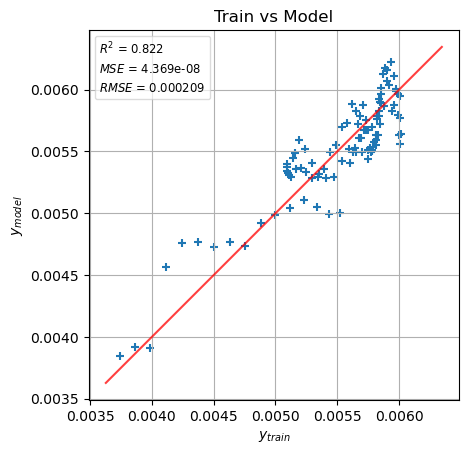

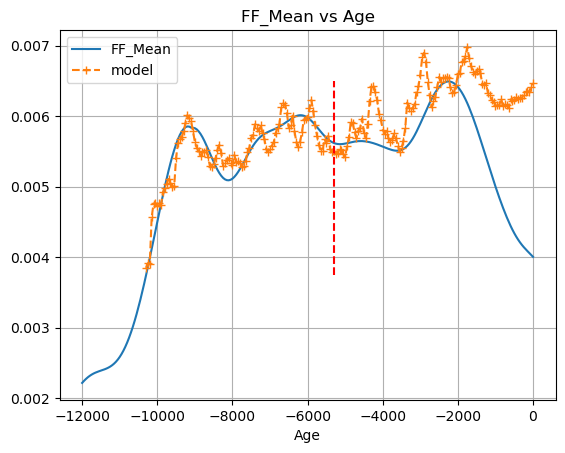

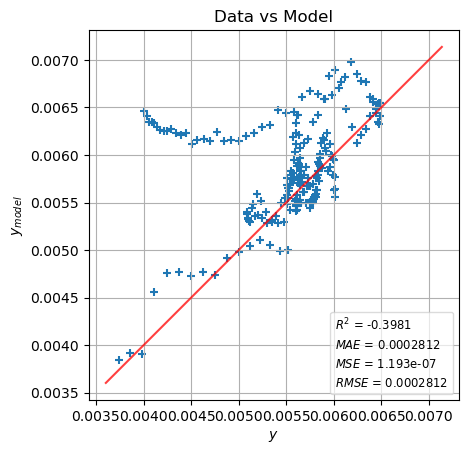

In [ ]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
features = df_data.columns.values[1:-3]
features = np.array(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus',
       'Betula', 'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae',
       'PRECT'], dtype=object)
y_target=['FF_Mean']#,'FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]
    # Create features X and target y.


    # Split the dataset into training (usually 75%) and testing (25%) sets.
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    tt=100
    X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    print(f"Root mean squared error: {rmse}")
    # accuracy = accuracy_score(y_test,y_pred)
    # print(f"Accuracy score: {accuracy:.4f}")

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############# plot correlation plots #######################
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel(r'$y_{test}$')
    ax.set_ylabel(r'$y_{pred}$')
    ax.set_title('Test vs Predictions')
    # squared plot
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # create a list with two empty handles (or more if needed)
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)

    fig, ax = plt.subplots()

    ax.scatter(x=y_train,y=b+df_model_train,marker='+')
    ax.set_xlabel(r'$y_{train}$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Train vs Model')
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()

    r2 = r2_score(y_train, b+df_model_train)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_train, b+df_model_train)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure
    fig, ax = plt.subplots()
    df_annual.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.vlines(x=df_data.Age[tt],ymin=np.min(df_data[y_target[k]]),ymax=np.max(df_data[y_target[k]]),color='r',linestyle='--')
    ax.grid()

    fig, ax = plt.subplots()
    ax.scatter(x=y,y=b+df_model,marker='+')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 4

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


In [ ]:
coeff_df

,Feature,Coefficient
0,Abies,0.000075
1,Cupressaceae,-0.000181
2,Larix,0.000123
3,Picea,-0.000064
4,Pinus,0.000224
5,Alnus,0.000074
6,Betula,0.000103
7,Asteraceae,0.000189
8,Chenopodium,-0.000030
9,Cyperaceae,-0.000167


### predire

R-squared: -0.5289989246368318
Mean squared error: 6.722488914505584e-07
Root mean squared error: 0.0008199078554633797
Intercept: 0.005500321570000001

Feature Coefficients:
          Feature  Coefficient
0          Abies     0.000129
1   Cupressaceae    -0.000079
2          Larix     0.000015
3          Picea     0.000151
4          Pinus     0.000209
5          Alnus    -0.000058
6         Betula    -0.000005
7        Populus     0.000027
8        Quercus     0.000259
9          Salix    -0.000051
10         Ulmus     0.000048
11      Ambrosia    -0.000025
12     Artemisia     0.000135
13    Asteraceae     0.000041
14   Chenopodium     0.000001
15    Cyperaceae    -0.000023
16       Poaceae     0.000155
17      Aquatics    -0.000007
18            TS     0.000150
19         PRECT     0.000053
20         human     0.000001
R-squared: 0.902243615602856
Mean squared error: 2.3992353572909224e-08


C:\Users\leoge\AppData\Local\Temp\ipykernel_18988\2391299401.py:181: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


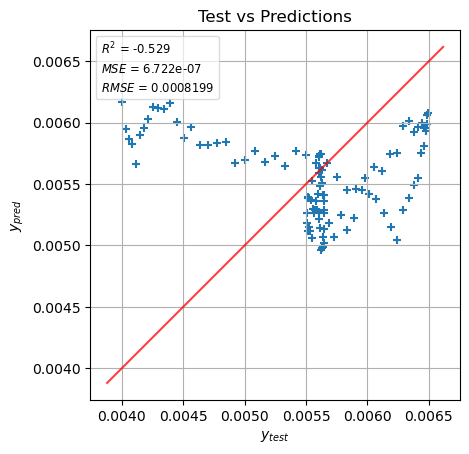

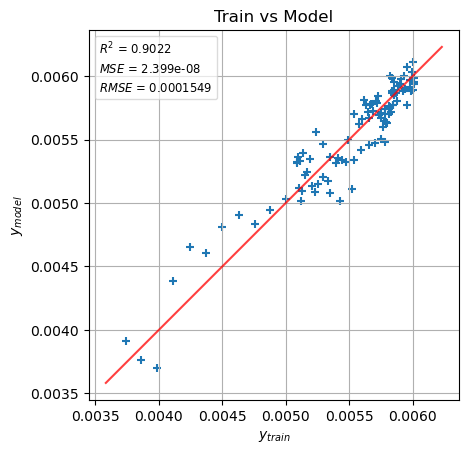

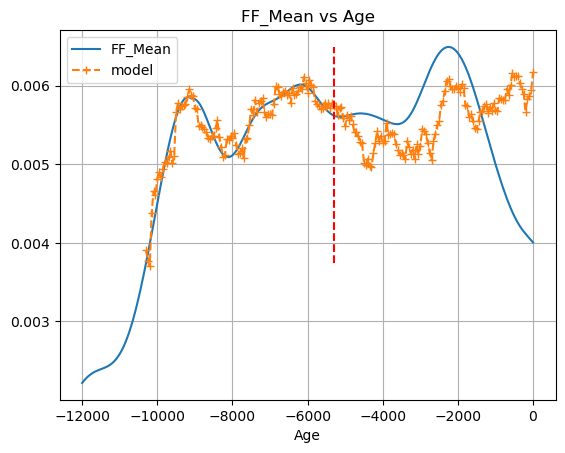

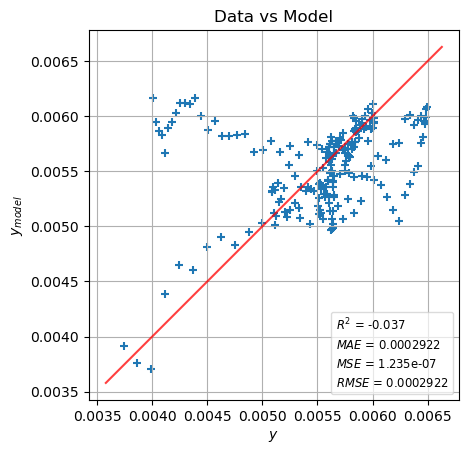

In [ ]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
features = df_data.columns.values[1:-3]
y_target=['FF_Mean']#,'FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]
    # Create features X and target y.


    # Split the dataset into training (usually 75%) and testing (25%) sets.
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    tt=100
    X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    print(f"Root mean squared error: {rmse}")
    # accuracy = accuracy_score(y_test,y_pred)
    # print(f"Accuracy score: {accuracy:.4f}")

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############# plot correlation plots #######################
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel(r'$y_{test}$')
    ax.set_ylabel(r'$y_{pred}$')
    ax.set_title('Test vs Predictions')
    # squared plot
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # create a list with two empty handles (or more if needed)
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)

    fig, ax = plt.subplots()

    ax.scatter(x=y_train,y=b+df_model_train,marker='+')
    ax.set_xlabel(r'$y_{train}$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Train vs Model')
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()

    r2 = r2_score(y_train, b+df_model_train)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_train, b+df_model_train)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure
    fig, ax = plt.subplots()
    df_annual.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.grid()
    ax.vlines(x=df_data['Age'][tt],ymin=min(df_data[y_target[k]]),ymax=max(df_data[y_target[k]]),color='r',linestyle='--')


    fig, ax = plt.subplots()
    ax.scatter(x=y,y=b+df_model,marker='+')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 4

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


In [ ]:
coeff_df[np.abs(coeff_df['Coefficient'])>0.0001].Feature

0         Abies
3         Picea
4         Pinus
8       Quercus
12    Artemisia
16      Poaceae
18           TS
Name: Feature, dtype: object

FF_Mean
R-squared: -0.7637989066696533
Mean absolute error: 0.0005928132834659687
Mean squared error: 7.754824680677993e-07
Root mean squared error: 0.0008806148238973719

 Cross val score
MAE: 0.00026332849167413376 0.00018698009862137157
MSE: 1.0430345180783217e-07 1.2485741615439816e-07
RMSE: 0.00026332849167413376 0.00018698009862137157
Accuracy: nan nan

 Intercept: 0.00382081890267054
Feature Coefficients:
          Feature   Coefficient
0            Age  3.592210e-08
1          Abies  2.691699e-04
2   Cupressaceae -9.000036e-05
3          Larix  9.064910e-05
4          Picea  5.389717e-05
5          Pinus  1.973391e-05
6          Alnus -4.778273e-05
7         Betula -3.527808e-07
8        Populus  4.846128e-05
9        Quercus  6.890427e-05
10         Salix -1.404835e-04
11         Ulmus  2.002699e-04
12      Ambrosia -2.286333e-05
13     Artemisia  1.498556e-04
14    Asteraceae  1.416929e-04
15   Chenopodium  1.440971e-05
16    Cyperaceae -7.562155e-05
17       Poaceae  8.95784

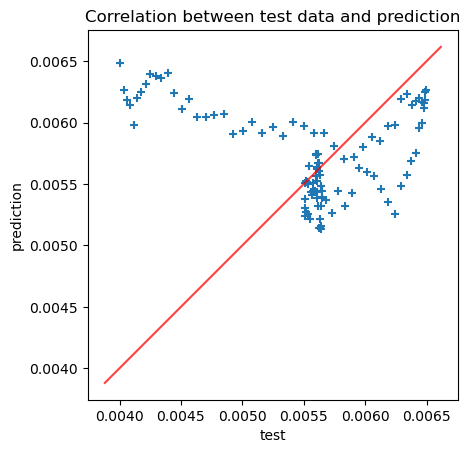

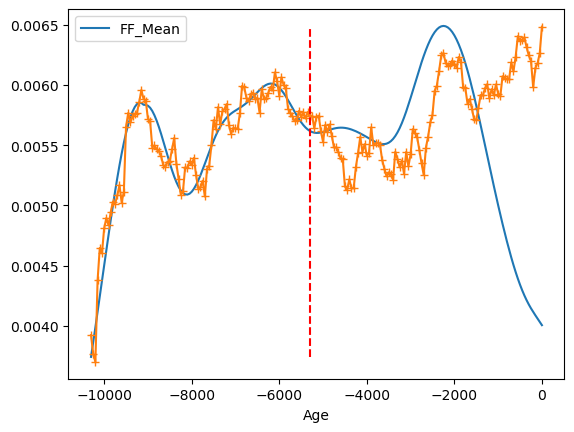

BB_Mean
R-squared: -2.785427845894199
Mean absolute error: 0.04578369639527719
Mean squared error: 0.0032522450779992845
Root mean squared error: 0.057028458492223724

 Cross val score
MAE: 0.015642786034177653 0.012845321354778878
MSE: 0.0004096990356186017 0.0007196456101306658
RMSE: 0.015642786034177653 0.012845321354778878
Accuracy: nan nan

 Intercept: -0.020097958647061334
Feature Coefficients:
          Feature    Coefficient
0            Age      -0.000006
1          Abies       0.030302
2   Cupressaceae       0.000215
3          Larix       0.028766
4          Picea      -0.003824
5          Pinus       0.001182
6          Alnus      -0.004584
7         Betula      -0.004971
8        Populus       0.010998
9        Quercus       0.005368
10         Salix      -0.035189
11         Ulmus       0.026496
12      Ambrosia       0.003903
13     Artemisia      -0.002207
14    Asteraceae      -0.006563
15   Chenopodium       0.003885
16    Cyperaceae      -0.004792
17       Poaceae   

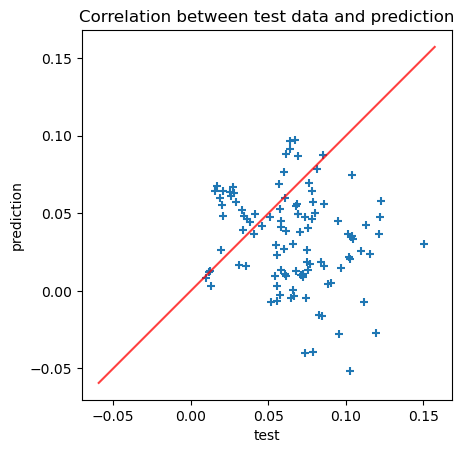

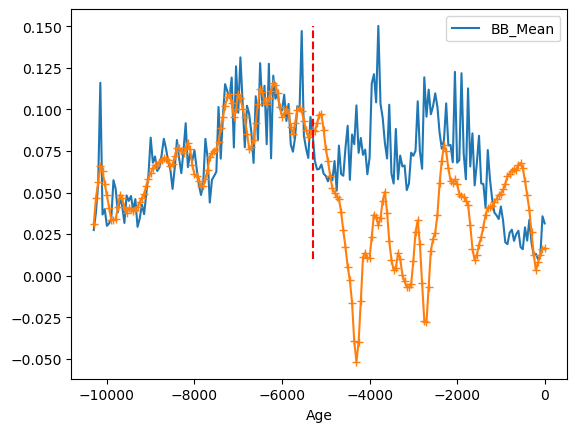

FS_Mean
R-squared: -1.3844193113279988
Mean absolute error: 0.03708847805139613
Mean squared error: 0.002539067042173422
Root mean squared error: 0.05038915599782777

 Cross val score
MAE: 0.019380991367814154 0.01762875727854279
MSE: 0.000686395909585062 0.0014597534399595517
RMSE: 0.019380991367814154 0.01762875727854279
Accuracy: nan nan

 Intercept: 0.6495321790142218
Feature Coefficients:
          Feature    Coefficient
0            Age      -0.000006
1          Abies       0.037075
2   Cupressaceae       0.002950
3          Larix       0.021132
4          Picea      -0.006874
5          Pinus       0.000457
6          Alnus      -0.003656
7         Betula      -0.004487
8        Populus       0.015851
9        Quercus       0.003194
10         Salix      -0.049105
11         Ulmus       0.017881
12      Ambrosia       0.005052
13     Artemisia      -0.015053
14    Asteraceae      -0.011619
15   Chenopodium       0.000441
16    Cyperaceae      -0.015167
17       Poaceae       0.0

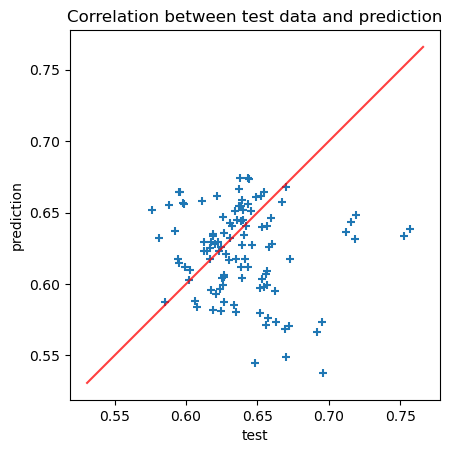

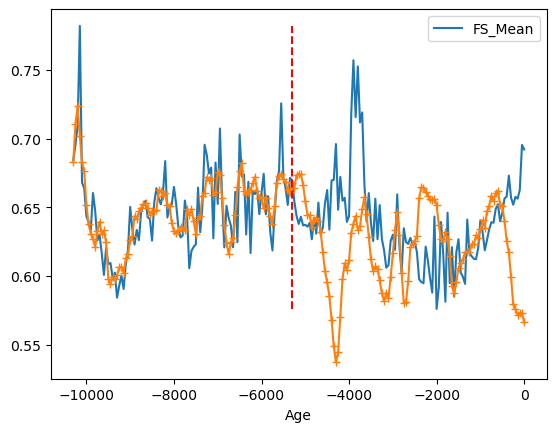

In [ ]:
# Import train_test_split.
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score

cv=LeaveOneOut()
# Create features X and target y.
features = df_data.columns.values[:-3]
y_target=['FF_Mean','BB_Mean','FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]

    print(y_target[k])

    # Split the dataset into training (80%) and testing (20%) sets.
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)
    tt=100
    X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    
    # Import StandardScaler.
    from sklearn.preprocessing import StandardScaler

    # Instantiate StandardScaler.
    scaler = StandardScaler()
    #utilisé pour supprimer la moyenne et mettre les caractéristiques 
    #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
    # dominent le modèle en raison de différences d'échelle.

    # Fit and transform training data.
    X_train_scaled = X_train # scaler.fit_transform(X_train)   # X_train

    # Also transform test data.
    X_test_scaled = X_test #scaler.transform(X_test)    # X_test 

    # Import LinearRegression.
    from sklearn.linear_model import LinearRegression

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Import metrics.
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score

    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print("R-squared:", r2)

    # Calculate and print MSE.
    mae= mean_absolute_error(y_test, y_pred)
    print("Mean absolute error:", mae)    
    mse = mean_squared_error(y_test, y_pred)
    print("Mean squared error:", mse)
    # Calculate and print RMSE.
    rmse = math.sqrt(mse)
    print("Root mean squared error:", rmse)

    print('\n Cross val score')

    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_absolute_error',
                           cv=cv,
                           n_jobs=-1)
    print("MAE:", np.mean(abs(scores)), np.std(scores))
    
    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("MSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='neg_root_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("RMSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='accuracy',
                           cv=cv,
                           n_jobs=-1)
    print("Accuracy:", np.mean(abs(scores)), np.std(scores))


    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("\n Intercept:", b)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("Feature Coefficients:\n", coeff_df)

    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel('test')
    ax.set_ylabel('prediction')
    ax.set_title('Correlation between test data and prediction')

    # plt.line
    # plt.xlim(min(y_test),max(y_test))
    # plt.ylim(min(y_pred),max(y_pred))

    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    # plt.axis('square')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)

    plt.show()


    #### dataframe of obtained model
    df_model=X

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 

    df_model = df_model.sum(axis=1)


    fig, ax = plt.subplots()

    df_data.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='-')
    ax.vlines(x=df_data['Age'][tt],ymin=min(df_data[y_target[k]]),ymax=max(df_data[y_target[k]]),color='r',linestyle='--')

    plt.show()




FF_Mean
R-squared: -1.437042106367644
Mean absolute error: 0.0010604291887353946
Mean squared error: 1.9441426069894487e-06
Root mean squared error: 0.0013943251439278604

 Cross val score
MAE: 0.00026332849167413376 0.00018698009862137157
MSE: 1.0430345180783217e-07 1.2485741615439816e-07
RMSE: 0.00026332849167413376 0.00018698009862137157
Accuracy: nan nan

 Intercept: 0.004096903137532627
Feature Coefficients:
          Feature   Coefficient
0            Age  8.256209e-08
1          Abies  1.284338e-04
2   Cupressaceae -9.966822e-05
3          Larix  9.945500e-05
4          Picea  6.895406e-05
5          Pinus  1.724396e-05
6          Alnus -1.389751e-05
7         Betula  1.370242e-05
8        Populus  2.029632e-05
9        Quercus  4.993268e-05
10         Salix -2.678888e-05
11         Ulmus  1.053345e-04
12      Ambrosia -2.117927e-05
13     Artemisia  1.065180e-04
14    Asteraceae  1.887665e-04
15   Chenopodium  8.693766e-05
16    Cyperaceae -1.448787e-04
17       Poaceae  9.1777

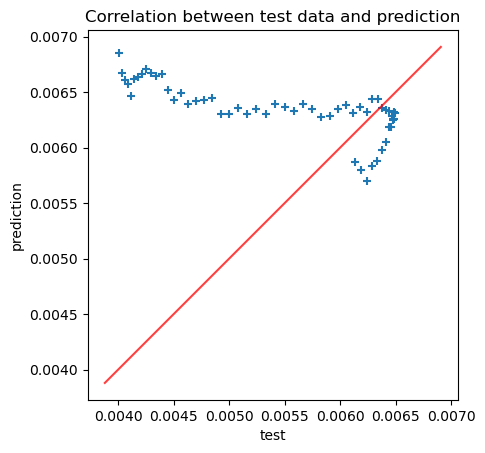

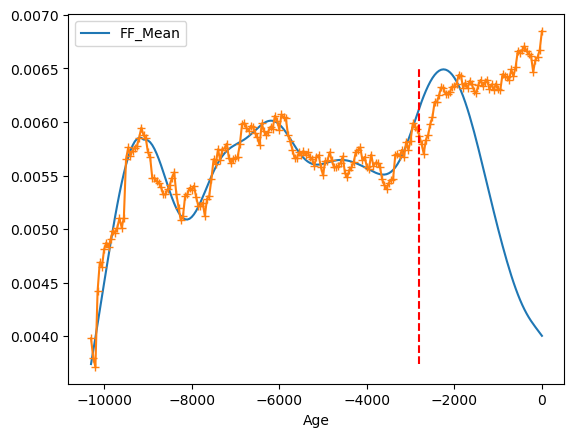

BB_Mean
R-squared: -4.364801491306296
Mean absolute error: 0.0654875836071715
Mean squared error: 0.005935883349383669
Root mean squared error: 0.0770446841085332

 Cross val score
MAE: 0.015642786034177653 0.012845321354778878
MSE: 0.0004096990356186017 0.0007196456101306658
RMSE: 0.015642786034177653 0.012845321354778878
Accuracy: nan nan

 Intercept: 0.19662980197689345
Feature Coefficients:
          Feature   Coefficient
0            Age  1.270482e-05
1          Abies  9.183108e-03
2   Cupressaceae -6.024765e-03
3          Larix -2.908518e-02
4          Picea -9.398534e-04
5          Pinus  1.856502e-04
6          Alnus -3.982864e-03
7         Betula -2.016580e-03
8        Populus -7.752228e-03
9        Quercus -3.167018e-03
10         Salix -1.527892e-02
11         Ulmus  1.034066e-02
12      Ambrosia  9.452799e-04
13     Artemisia -4.909759e-03
14    Asteraceae  3.174141e-03
15   Chenopodium  1.397699e-02
16    Cyperaceae -1.862936e-03
17       Poaceae  3.112207e-03
18      Aqua

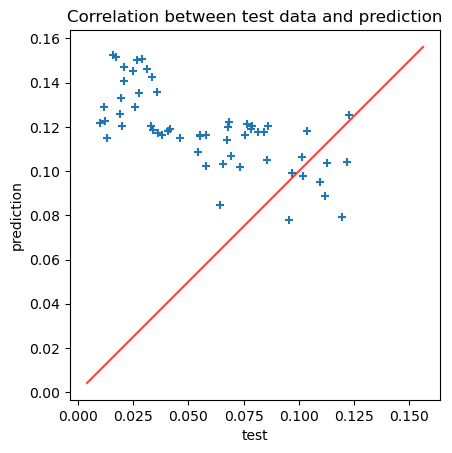

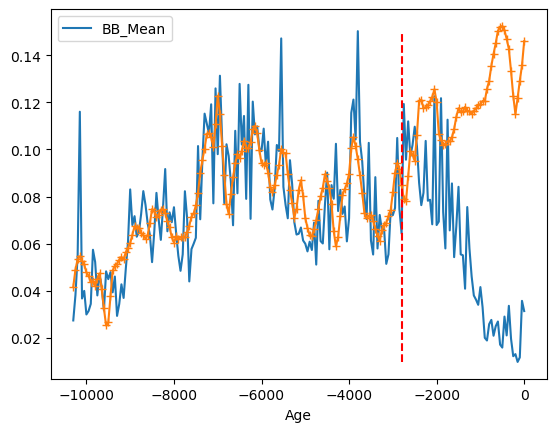

FS_Mean
R-squared: -2.001311067760934
Mean absolute error: 0.037878845256818484
Mean squared error: 0.00205617981948294
Root mean squared error: 0.045345119026009184

 Cross val score
MAE: 0.019380991367814154 0.01762875727854279
MSE: 0.000686395909585062 0.0014597534399595517
RMSE: 0.019380991367814154 0.01762875727854279
Accuracy: nan nan

 Intercept: 0.8793742071722584
Feature Coefficients:
          Feature   Coefficient
0            Age  1.036486e-05
1          Abies  1.248455e-02
2   Cupressaceae -2.267050e-03
3          Larix -5.417946e-02
4          Picea -4.522077e-03
5          Pinus -5.780277e-04
6          Alnus -6.782197e-03
7         Betula -2.302127e-03
8        Populus -2.941872e-03
9        Quercus -5.020203e-03
10         Salix -2.212619e-02
11         Ulmus  8.395780e-04
12      Ambrosia -9.309608e-04
13     Artemisia -1.357689e-02
14    Asteraceae -1.129194e-02
15   Chenopodium  9.843628e-03
16    Cyperaceae  7.573980e-03
17       Poaceae -1.694496e-03
18      Aquat

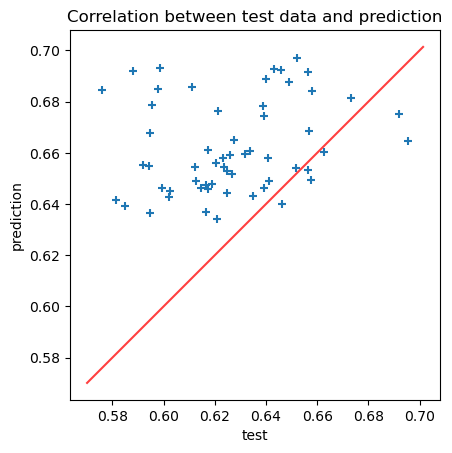

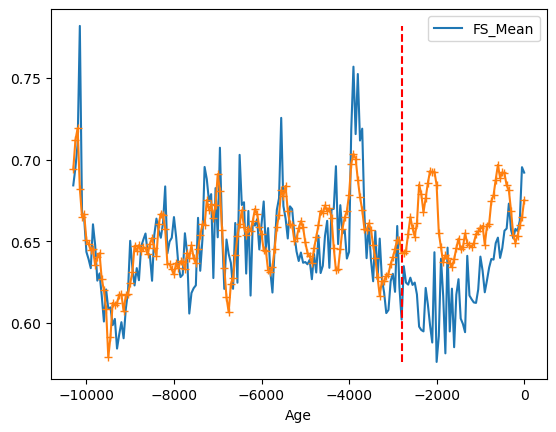

In [ ]:
# Import train_test_split.
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score

cv=LeaveOneOut()
# Create features X and target y.
features = df_data.columns.values[:-3]
y_target=['FF_Mean','BB_Mean','FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]

    print(y_target[k])

    # Split the dataset into training (80%) and testing (20%) sets.
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)
    tt=150
    X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    
    # Import StandardScaler.
    from sklearn.preprocessing import StandardScaler

    # Instantiate StandardScaler.
    scaler = StandardScaler()
    #utilisé pour supprimer la moyenne et mettre les caractéristiques 
    #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
    # dominent le modèle en raison de différences d'échelle.

    # Fit and transform training data.
    X_train_scaled = X_train # scaler.fit_transform(X_train)   # X_train

    # Also transform test data.
    X_test_scaled = X_test #scaler.transform(X_test)    # X_test 

    # Import LinearRegression.
    from sklearn.linear_model import LinearRegression


    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Import metrics.
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score

    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print("R-squared:", r2)

    # Calculate and print MSE.
    mae= mean_absolute_error(y_test, y_pred)
    print("Mean absolute error:", mae)    
    mse = mean_squared_error(y_test, y_pred)
    print("Mean squared error:", mse)
    # Calculate and print RMSE.
    rmse = math.sqrt(mse)
    print("Root mean squared error:", rmse)

    print('\n Cross val score')

    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_absolute_error',
                           cv=cv,
                           n_jobs=-1)
    print("MAE:", np.mean(abs(scores)), np.std(scores))
    
    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("MSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='neg_root_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("RMSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='accuracy',
                           cv=cv,
                           n_jobs=-1)
    print("Accuracy:", np.mean(abs(scores)), np.std(scores))


    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("\n Intercept:", b)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("Feature Coefficients:\n", coeff_df)

    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel('test')
    ax.set_ylabel('prediction')
    ax.set_title('Correlation between test data and prediction')

    # plt.line
    # plt.xlim(min(y_test),max(y_test))
    # plt.ylim(min(y_pred),max(y_pred))

    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    # plt.axis('square')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)

    plt.show()


    #### dataframe of obtained model
    df_model=X

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 

    df_model = df_model.sum(axis=1)


    fig, ax = plt.subplots()

    df_data.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='-')

    ax.vlines(x=df_data['Age'][tt],ymin=min(df_data[y_target[k]]),ymax=max(df_data[y_target[k]]),color='r',linestyle='--')

    plt.show()




# Gaussian model

FF_Mean


c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__alpha is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\ker


 Cross val score
MAE: 0.00024661505798124215 0.0003848519365820345
MSE: 1.673976693164967e-07 4.3580551934928535e-07
RMSE: 0.0002404603410992553 0.00035504496318683763
Accuracy: nan nan


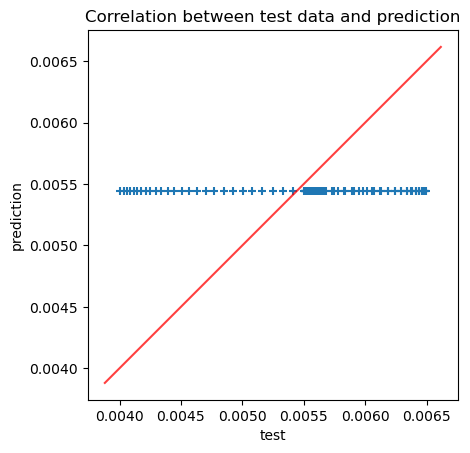

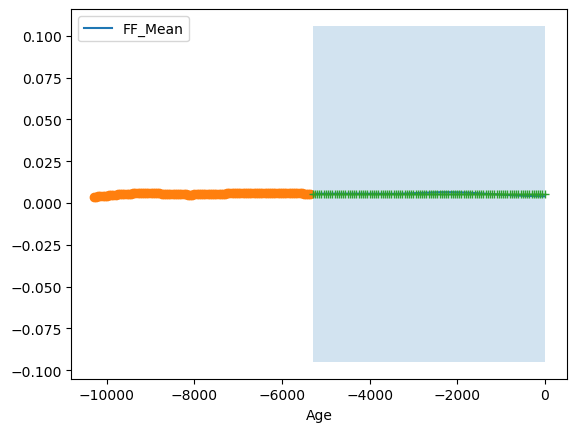

In [49]:
# Import train_test_split.
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern, RationalQuadratic, WhiteKernel

# définir kernel et entraîner modèle
# kernel =  RBF(2.0, (1e-3, 1e3)) #* C(1.0, (1e-3, 1e3)) 
kernel = Matern(length_scale=1.0, nu=1.5)
# kernel = RationalQuadratic(length_scale=1.0, alpha=0.5) * Matern(length_scale=1.0, nu=1.5)
kernel = WhiteKernel(noise_level=0.1)  +   RBF(1.0) 
kernel = C(1.0, (1e-2, 1e2)) * (RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3))
    + RationalQuadratic(length_scale=1.0, alpha=1.0)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))

cv=LeaveOneOut()

# Create features X and target y.
features = df_data.columns.values[:-3]
y_target=['FF_Mean']#,'BB_Mean','FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]

    print(y_target[k])
    
    # Split the dataset into training (80%) and testing (20%) sets.
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    tt=100
    
    X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # X=df_data[df_data.columns.values[:-3]]
    
    # Import StandardScaler.
    from sklearn.preprocessing import StandardScaler

    # Instantiate StandardScaler.
    scaler = StandardScaler()
    #utilisé pour supprimer la moyenne et mettre les caractéristiques 
    #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
    # dominent le modèle en raison de différences d'échelle.

    # Fit and transform training data.
    X_train_scaled = X_train # scaler.fit_transform(X_train)   # X_train

    # Also transform test data.
    X_test_scaled = X_test #scaler.transform(X_test)    # X_test 

    # Import LinearRegression.
    # from sklearn.linear_model import LinearRegression
    # from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
    from sklearn.gaussian_process import GaussianProcessRegressor
    
    # Instantiate linear regression model.
    model = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=3)
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    # y_pred = model.predict(X_test_scaled)

    # X_pred = np.atleast_2d(np.linspace(0, 10, 200)).T
    y_pred, y_std = model.predict(X_test_scaled.sort_index(), return_std=True)

    ############ performance of model #################""
    # Import metrics.
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score


    print('\n Cross val score')

    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_absolute_error',
                           cv=cv,
                           n_jobs=-1)
    print("MAE:", np.mean(abs(scores)), np.std(scores))
    
    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("MSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='neg_root_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("RMSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='accuracy',
                           cv=cv,
                           n_jobs=-1)
    print("Accuracy:", np.mean(abs(scores)), np.std(scores))



    
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel('test')
    ax.set_ylabel('prediction')
    ax.set_title('Correlation between test data and prediction')

    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    # plt.axis('square')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)

    plt.show()


    fig, ax = plt.subplots()

    df_data.plot(x='Age',y=y_target[k],ax=ax)
    plt.plot(X_train_scaled.Age,y_train,label='training data',marker='o')
    plt.plot(X_test_scaled.Age.values, y_pred, label="Prédiction GPR",marker='+',linestyle='')
    plt.fill_between(X_test_scaled.Age.values,
                     y_pred - y_std,
                     y_pred + y_std,
                     alpha=0.2,
                     label="Intervalle de confiance 95%",
                     )
    
 
 

AttributeError: 'DataFrame' object has no attribute 'Age'

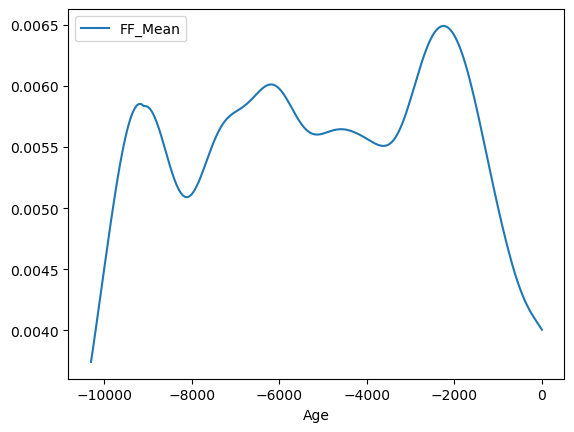

In [53]:
fig, ax = plt.subplots()
df_data.plot(x='Age',y=y_target[k],ax=ax)
plt.plot(X_train_scaled.Age,y_train,label='training data',marker='o')
plt.plot(X_test_scaled.Age.values, y_pred, label="Prédiction GPR",marker='+',linestyle='')
plt.legend()

FF_Mean


c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__alpha is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\leoge\anaconda3\Lib\site-packages\sklearn\gaussian_process\ker


 Cross val score
MAE: 0.00022726695844059626 0.00035161626044736665
MSE: 1.7940964105800964e-07 4.358496998365068e-07
RMSE: 0.00023184322558781717 0.00037924872907929905
Accuracy: nan nan


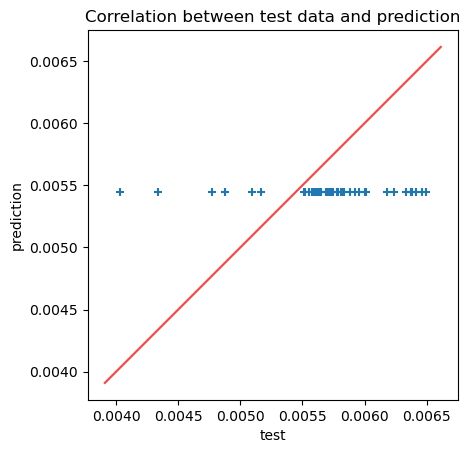

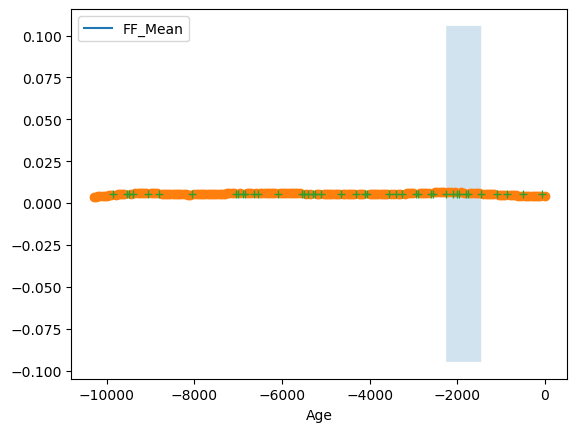

In [50]:
# Import train_test_split.
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern, RationalQuadratic, WhiteKernel

# définir kernel et entraîner modèle
# kernel =  RBF(2.0, (1e-3, 1e3)) #* C(1.0, (1e-3, 1e3)) 
kernel = Matern(length_scale=1.0, nu=1.5)
# kernel = RationalQuadratic(length_scale=1.0, alpha=0.5) * Matern(length_scale=1.0, nu=1.5)
kernel = WhiteKernel(noise_level=0.1)  +   RBF(1.0) 
kernel = C(1.0, (1e-2, 1e2)) * (RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3))
    + RationalQuadratic(length_scale=1.0, alpha=1.0)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))

cv=LeaveOneOut()

# Create features X and target y.
features = df_data.columns.values[:-3]
y_target=['FF_Mean']#,'BB_Mean','FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]

    print(y_target[k])
    
    # Split the dataset into training (80%) and testing (20%) sets.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # tt=100
    
    # X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # X=df_data[df_data.columns.values[:-3]]
    
    # Import StandardScaler.
    from sklearn.preprocessing import StandardScaler

    # Instantiate StandardScaler.
    scaler = StandardScaler()
    #utilisé pour supprimer la moyenne et mettre les caractéristiques 
    #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
    # dominent le modèle en raison de différences d'échelle.

    # Fit and transform training data.
    X_train_scaled = X_train # scaler.fit_transform(X_train)   # X_train

    # Also transform test data.
    X_test_scaled = X_test #scaler.transform(X_test)    # X_test 

    # Import LinearRegression.
    # from sklearn.linear_model import LinearRegression
    # from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
    from sklearn.gaussian_process import GaussianProcessRegressor
    
    # Instantiate linear regression model.
    model = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=3)
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    # y_pred = model.predict(X_test_scaled)

    # X_pred = np.atleast_2d(np.linspace(0, 10, 200)).T
    y_pred, y_std = model.predict(X_test_scaled.sort_index(), return_std=True)

    ############ performance of model #################""
    # Import metrics.
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score


    print('\n Cross val score')

    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_absolute_error',
                           cv=cv,
                           n_jobs=-1)
    print("MAE:", np.mean(abs(scores)), np.std(scores))
    
    scores=cross_val_score(model,X,y,
                           scoring='neg_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("MSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='neg_root_mean_squared_error',
                           cv=cv,
                           n_jobs=-1)
    print("RMSE:", np.mean(abs(scores)), np.std(scores))

    scores=cross_val_score(model,X,y,
                           scoring='accuracy',
                           cv=cv,
                           n_jobs=-1)
    print("Accuracy:", np.mean(abs(scores)), np.std(scores))



    
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel('test')
    ax.set_ylabel('prediction')
    ax.set_title('Correlation between test data and prediction')

    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    # plt.axis('square')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)

    plt.show()


    fig, ax = plt.subplots()

    df_data.plot(x='Age',y=y_target[k],ax=ax)
    plt.plot(X_train_scaled.Age,y_train,label='training data',marker='o')
    plt.plot(X_test_scaled.Age.values, y_pred, label="Prédiction GPR",marker='+',linestyle='')
    plt.fill_between(X_test_scaled.Age.values,
                     y_pred - y_std,
                     y_pred + y_std,
                     alpha=0.2,
                     label="Intervalle de confiance 95%",
                     )
    
 
 

AttributeError: 'DataFrame' object has no attribute 'Age'

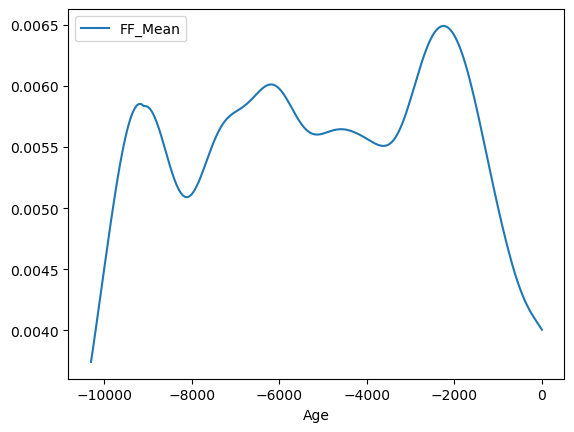

In [56]:
fig, ax = plt.subplots()


df_data.plot(x='Age',y=y_target[k],ax=ax)
plt.plot(X_train_scaled.Age,y_train,label='training data',marker='o')
plt.plot(X_test_scaled.Age.values, y_pred, label="Prédiction GPR",marker='+',linestyle='')
plt.fill_between(X_test_scaled.Age.values,
            
                    alpha=0.2,
                    label="Intervalle de confiance 95%",
                    )